In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [2]:
data = pd.read_csv("../Data/processed_data.csv", encoding="utf-8")

In [3]:
pd.set_option('display.max_columns', None)
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes
0,0,0,1,0,1,0,1,0,0,0,0,0,1,29.85,29.85,0,True,False,False,False,False,True,False,False,True,False
1,1,0,0,0,34,1,0,1,0,0,0,1,0,56.95,1889.50,0,True,False,False,False,False,False,True,True,False,False
2,1,0,0,0,2,1,1,0,0,0,0,0,1,53.85,108.15,1,True,False,False,False,False,False,True,True,False,False
3,1,0,0,0,45,1,0,1,1,0,0,1,0,42.30,1840.75,0,True,False,False,True,False,False,False,False,True,False
4,0,0,0,0,2,0,0,0,0,0,0,0,1,70.70,151.65,1,False,True,False,False,False,True,False,True,False,False


In [15]:
data['Churn'].value_counts()

Churn
0    5165
1    1857
Name: count, dtype: int64

In [16]:
x = data.drop(columns="Churn", axis=1)
y = data["Churn"]
smote = SMOTE(random_state=42)
x, y = smote.fit_resample(x, y)

In [18]:
y.value_counts()

Churn
0    5165
1    5165
Name: count, dtype: int64

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [8]:
Forest = RandomForestClassifier()

In [9]:
# param_grid_forest = {
#     "n_estimators": [100, 200, 300, 400, 500, 1000],
#     "criterion": ["gini", "entropy"],
#     "max_depth": [None, 10, 20, 30, 40, 50],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 4],
# }

# grid_search_Forest = GridSearchCV(
#     estimator=Forest, param_grid=param_grid_forest, cv=5, n_jobs=-1, verbose=2
# )

# grid_search_Forest.fit(x_train, y_train)

# print("Best parameters found: ", grid_search.best_params_)
# print("Best cross-validation score: ", grid_search.best_score_)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Best parameters found:  {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 5}
Best cross-validation score:  0.7668362156663276

In [10]:
BestForest = RandomForestClassifier(criterion = 'entropy', max_depth= 10, min_samples_leaf= 4, min_samples_split= 5)

In [11]:
BestForest.fit(x_train, y_train)
y_prob = BestForest.predict_proba(x_test)[:, 1]
custom_threshold = 0.35
y_pred_custom = (y_prob >= custom_threshold).astype(int)

In [12]:
print("\nClassification Report with Custom Threshold:")
print(classification_report(y_test, y_pred_custom))

f1 = f1_score(y_test, y_pred_custom, average="weighted")
print(f"Weighted F1-Score:{f1:.2f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_custom):.2f}")


Classification Report with Custom Threshold:
              precision    recall  f1-score   support

           0       0.93      0.70      0.80      1552
           1       0.76      0.95      0.84      1547

    accuracy                           0.82      3099
   macro avg       0.84      0.82      0.82      3099
weighted avg       0.84      0.82      0.82      3099

Weighted F1-Score:0.82
Accuracy: 0.82


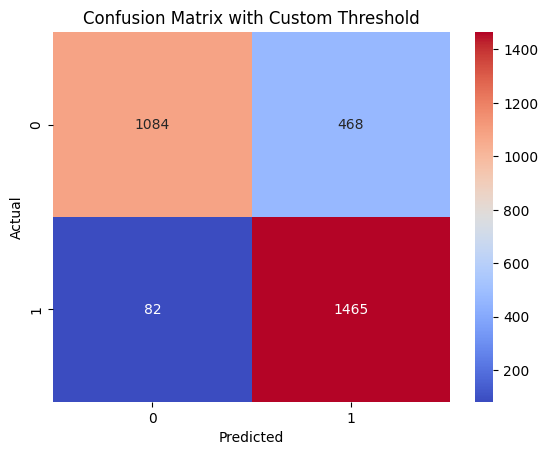

In [13]:
cm = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix with Custom Threshold")
plt.show()

## This is the classification report for Logistic regression

Classification Report with Custom Threshold:

              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1552
           1       0.77      0.93      0.84      1547

    accuracy                           0.83      3099

Weighted F1-Score: 0.83

Accuracy: 0.83

## This is the classification report for RandomForestClassifier

Classification Report with Custom Threshold:

              precision    recall  f1-score   support

           0       0.93      0.70      0.80      1552
           1       0.76      0.95      0.84      1547

    accuracy                           0.82      3099

Weighted F1-Score:0.82

Accuracy: 0.82

### You can see that the two models give the same accuracy but the difference that the Random forest can increase the class one recall so it depends on the buisness if It need more accuracy in general or decreasing the false negative as possible 

### Here I will go with the RandomForest